# Diffusion Model Image Generation Evaluation
### Roll Number: MSDS25011
### Name: Talal

This notebook demonstrates the evaluation of the trained Diffusion Model on our animal subset dataset.

In [ ]:
import os
import glob
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from torchvision.utils import make_grid

# Import model and functions from our script
from MSDS25011_05 import SimpleUNet, q_sample, sample_images, T, beta, alpha, alpha_cumprod, sqrt_alphas_cumprod, sqrt_one_minus_alphas_cumprod

: 

## 1. Visualizing the Forward Diffusion Process
We load a sample image from the dataset and apply Gaussian noise progressively over $T=1000$ steps.

Loading image: ../animal_data/Cat/Cat_1.jpeg


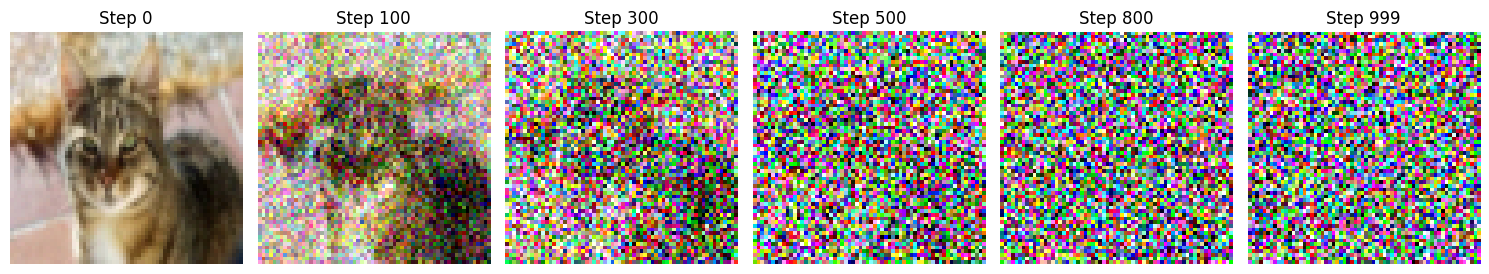

In [2]:
# Load a sample image
img_path = '../animal_data/Cat/Cat_1.jpeg'
if not os.path.exists(img_path):
    # Find any image in animal_data as fallback
    paths = glob.glob('../animal_data/*/*.jpeg') + glob.glob('../animal_data/*/*.jpg')
    if paths:
        img_path = paths[0]
    else:
        img_path = None

if img_path:
    print(f"Loading image: {img_path}")
    img = Image.open(img_path).convert('RGB')
    transform = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    x_0 = transform(img).unsqueeze(0) # Add batch dimension

    # Plot image at different steps
    steps = [0, 100, 300, 500, 800, 999]
    fig, axes = plt.subplots(1, len(steps), figsize=(15, 3))

    for idx, t_val in enumerate(steps):
        t = torch.tensor([t_val], dtype=torch.long)
        # Get noisy image at step t
        x_t = q_sample(x_0, t)
        
        # Denormalize to [0, 1] for plotting
        x_t_plot = (x_t.squeeze(0).permute(1, 2, 0) + 1.0) / 2.0
        x_t_plot = torch.clamp(x_t_plot, 0, 1).numpy()
        
        axes[idx].imshow(x_t_plot)
        axes[idx].set_title(f'Step {t_val}')
        axes[idx].axis('off')

    plt.tight_layout()
    plt.savefig('forward_noising_steps.png')
    plt.show()
else:
    print("Error: No image found for forward process visualization.")

## 2. Load the Trained Model Checkpoint

Using device: mps
Successfully loaded model trained for 300 epochs.


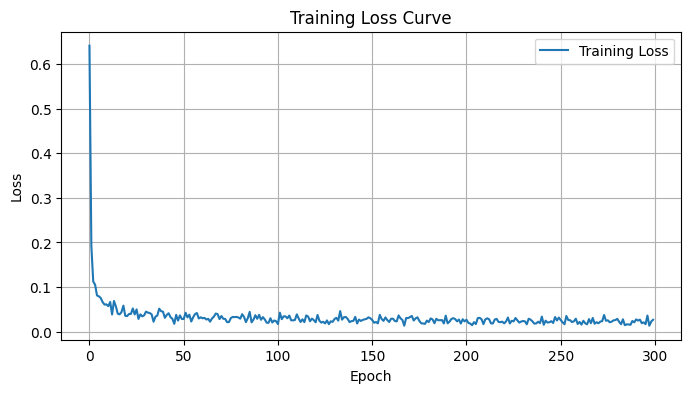

In [3]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Initialize model
model = SimpleUNet(time_emb_dim=128).to(device)

# Load checkpoint
checkpoint_path = 'saved_models/diffusion_model.pth'
if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Successfully loaded model trained for {checkpoint['epoch']} epochs.")
    
    # Plot training loss curve
    if 'losses' in checkpoint:
        plt.figure(figsize=(8, 4))
        plt.plot(checkpoint['losses'], label='Training Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Training Loss Curve')
        plt.grid(True)
        plt.legend()
        plt.show()
else:
    print(f"Warning: Checkpoint not found at {checkpoint_path}")

## 3. Generate New Images using Reverse Process
We sample pure Gaussian noise and run the reverse diffusion process to denoise it back into images.

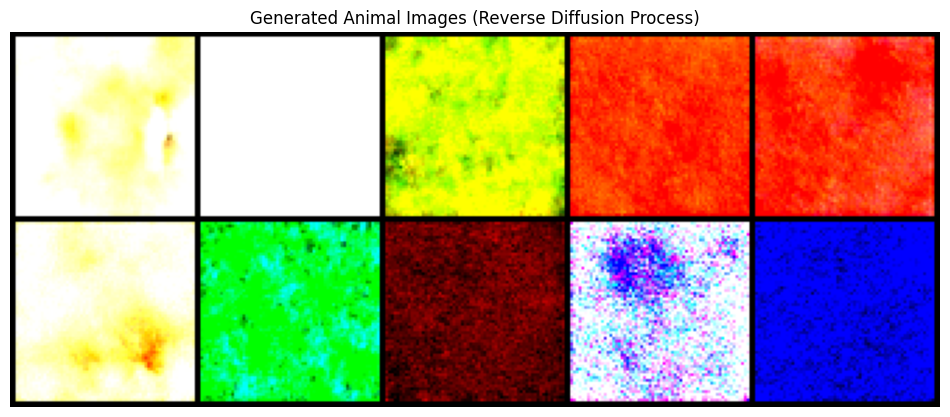

In [4]:
# Generate samples
n_samples = 10
generated_images = sample_images(model, n_samples=n_samples, img_size=64, device=device)

# Plot the generated samples in a grid
grid = make_grid(generated_images, nrow=5, padding=2)
grid_np = grid.cpu().permute(1, 2, 0).numpy()

plt.figure(figsize=(12, 6))
plt.imshow(grid_np)
plt.title('Generated Animal Images (Reverse Diffusion Process)')
plt.axis('off')
plt.savefig('generated_samples_eval.png')
plt.show()